# SupportOps AI - BANKING77 Baseline Intent Classifier

## Objective

Build and evaluate a classical NLP baseline for customer-support
intent classification using BANKING77.

### Pipeline

Customer Query → TF-IDF → Logistic Regression → Intent

### Evaluation

- Official BANKING77 test set
- Strict zero-overlap test set
- Accuracy
- Macro Precision
- Macro Recall
- Macro F1
- Per-class F1
- Error analysis

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


Load BANKING77

In [3]:
TRAIN_URL = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/train.csv"
)

TEST_URL = (
    "https://raw.githubusercontent.com/"
    "PolyAI-LDN/task-specific-datasets/"
    "master/banking_data/test.csv"
)

train_df = pd.read_csv(TRAIN_URL)
test_df = pd.read_csv(TEST_URL)

# Rename category → intent
train_df = train_df.rename(
    columns={"category": "intent"}
)

test_df = test_df.rename(
    columns={"category": "intent"}
)

# Keep only modelling columns
train_df = train_df[
    ["text", "intent"]
].copy()

test_df = test_df[
    ["text", "intent"]
].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

train_df.head()

Training shape: (10003, 2)
Testing shape: (3080, 2)


,text,intent
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [4]:
train_df.to_csv(
    "../data/raw/banking77_train.csv",
    index=False
)

test_df.to_csv(
    "../data/raw/banking77_test.csv",
    index=False
)

print("BANKING77 files saved locally!")

BANKING77 files saved locally!


Recreate normalization

In [5]:
def normalize_text(text):
    return " ".join(
        str(text)
        .lower()
        .strip()
        .split()
    )

In [6]:
train_df["normalized_text"] = (
    train_df["text"].apply(normalize_text)
)

test_df["normalized_text"] = (
    test_df["text"].apply(normalize_text)
)

Recreate the strict test set

In [7]:
train_normalized_texts = set(
    train_df["normalized_text"]
)

strict_test_df = test_df[
    ~test_df["normalized_text"].isin(
        train_normalized_texts
    )
].copy()

print("Official test size:", len(test_df))
print("Strict test size:", len(strict_test_df))

Official test size: 3080
Strict test size: 3073


In [8]:
strict_overlap = set(
    train_df["normalized_text"]
).intersection(
    set(strict_test_df["normalized_text"])
)

print(
    "Strict normalized overlap:",
    len(strict_overlap)
)

Strict normalized overlap: 0


Define training and testing variables

In [9]:
X_train = train_df["text"]
y_train = train_df["intent"]

X_test_official = test_df["text"]
y_test_official = test_df["intent"]

X_test_strict = strict_test_df["text"]
y_test_strict = strict_test_df["intent"]

In [10]:
print("Training examples:", len(X_train))
print("Official test examples:", len(X_test_official))
print("Strict test examples:", len(X_test_strict))

print("Number of intents:", y_train.nunique())

Training examples: 10003
Official test examples: 3080
Strict test examples: 3073
Number of intents: 77


Calculate simple chance baselines

In [11]:
random_chance = 1 / y_train.nunique()

print(
    f"Uniform random chance: {random_chance:.4f}"
)

Uniform random chance: 0.0130


In [12]:
majority_class = y_train.value_counts().idxmax()

majority_accuracy = (
    y_test_official == majority_class
).mean()

print("Majority class:", majority_class)
print(
    f"Majority-class accuracy: {majority_accuracy:.4f}"
)

Majority class: card_payment_fee_charged
Majority-class accuracy: 0.0130


Build TF-IDF + Logistic Regression

In [13]:
baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

Train the model

In [14]:
baseline_model.fit(
    X_train,
    y_train
)

print(
    "BANKING77 baseline model trained successfully!"
)

BANKING77 baseline model trained successfully!


Predict the official test set

In [15]:
official_pred = baseline_model.predict(
    X_test_official
)

print(
    "Official test predictions generated!"
)

Official test predictions generated!


Calculate official metrics

In [16]:
official_accuracy = accuracy_score(
    y_test_official,
    official_pred
)

official_precision = precision_score(
    y_test_official,
    official_pred,
    average="macro",
    zero_division=0
)

official_recall = recall_score(
    y_test_official,
    official_pred,
    average="macro",
    zero_division=0
)

official_f1 = f1_score(
    y_test_official,
    official_pred,
    average="macro",
    zero_division=0
)

print("OFFICIAL BANKING77 TEST RESULTS")
print("=" * 45)

print(
    f"Accuracy:        {official_accuracy:.4f}"
)

print(
    f"Macro Precision: {official_precision:.4f}"
)

print(
    f"Macro Recall:    {official_recall:.4f}"
)

print(
    f"Macro F1:        {official_f1:.4f}"
)

OFFICIAL BANKING77 TEST RESULTS
Accuracy:        0.8588
Macro Precision: 0.8681
Macro Recall:    0.8588
Macro F1:        0.8581


Evaluate the strict test set

In [17]:
strict_pred = baseline_model.predict(
    X_test_strict
)

In [18]:
strict_accuracy = accuracy_score(
    y_test_strict,
    strict_pred
)

strict_precision = precision_score(
    y_test_strict,
    strict_pred,
    average="macro",
    zero_division=0
)

strict_recall = recall_score(
    y_test_strict,
    strict_pred,
    average="macro",
    zero_division=0
)

strict_f1 = f1_score(
    y_test_strict,
    strict_pred,
    average="macro",
    zero_division=0
)

print("STRICT ZERO-OVERLAP TEST RESULTS")
print("=" * 45)

print(
    f"Accuracy:        {strict_accuracy:.4f}"
)

print(
    f"Macro Precision: {strict_precision:.4f}"
)

print(
    f"Macro Recall:    {strict_recall:.4f}"
)

print(
    f"Macro F1:        {strict_f1:.4f}"
)

STRICT ZERO-OVERLAP TEST RESULTS
Accuracy:        0.8584
Macro Precision: 0.8678
Macro Recall:    0.8583
Macro F1:        0.8576


Compare official vs strict

In [19]:
comparison_df = pd.DataFrame({
    "Evaluation": [
        "Official Test",
        "Strict Test"
    ],
    "Accuracy": [
        official_accuracy,
        strict_accuracy
    ],
    "Macro Precision": [
        official_precision,
        strict_precision
    ],
    "Macro Recall": [
        official_recall,
        strict_recall
    ],
    "Macro F1": [
        official_f1,
        strict_f1
    ]
})

comparison_df

,Evaluation,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Official Test,0.858766,0.868082,0.858766,0.858061
1,Strict Test,0.858445,0.867795,0.858270,0.857647


Generate the full classification report

In [20]:
official_report = classification_report(
    y_test_official,
    official_pred,
    output_dict=True,
    zero_division=0
)

official_report_df = (
    pd.DataFrame(official_report)
    .transpose()
)

official_report_df.head()

,precision,recall,f1-score,support
Refund_not_showing_up,0.883721,0.95,0.915663,40.0
activate_my_card,1.000000,0.95,0.974359,40.0
age_limit,1.000000,1.00,1.000000,40.0
apple_pay_or_google_pay,0.975610,1.00,0.987654,40.0
atm_support,0.864865,0.80,0.831169,40.0


Find the best-performing intents

In [21]:
class_report = official_report_df.loc[
    baseline_model.classes_
].copy()

best_classes = (
    class_report
    .sort_values(
        "f1-score",
        ascending=False
    )
    .head(10)
)

best_classes[
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
age_limit,1.000000,1.000,1.000000,40.0
verify_top_up,1.000000,1.000,1.000000,40.0
passcode_forgotten,1.000000,1.000,1.000000,40.0
edit_personal_details,0.975610,1.000,0.987654,40.0
apple_pay_or_google_pay,0.975610,1.000,0.987654,40.0
lost_or_stolen_phone,1.000000,0.975,0.987342,40.0
activate_my_card,1.000000,0.950,0.974359,40.0
change_pin,1.000000,0.925,0.961039,40.0
transaction_charged_twice,0.909091,1.000,0.952381,40.0
card_about_to_expire,0.909091,1.000,0.952381,40.0


Find the worst-performing intents

In [22]:
worst_classes = (
    class_report
    .sort_values(
        "f1-score",
        ascending=True
    )
    .head(10)
)

worst_classes[
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
virtual_card_not_working,1.000000,0.400,0.571429,40.0
card_not_working,0.600000,0.825,0.694737,40.0
balance_not_updated_after_bank_transfer,0.645833,0.775,0.704545,40.0
pending_transfer,0.862069,0.625,0.724638,40.0
card_payment_not_recognised,0.756757,0.700,0.727273,40.0
get_disposable_virtual_card,0.731707,0.750,0.740741,40.0
top_up_failed,0.731707,0.750,0.740741,40.0
wrong_exchange_rate_for_cash_withdrawal,0.870968,0.675,0.760563,40.0
compromised_card,0.805556,0.725,0.763158,40.0
extra_charge_on_statement,0.693878,0.850,0.764045,40.0


Plot the 15 worst intents

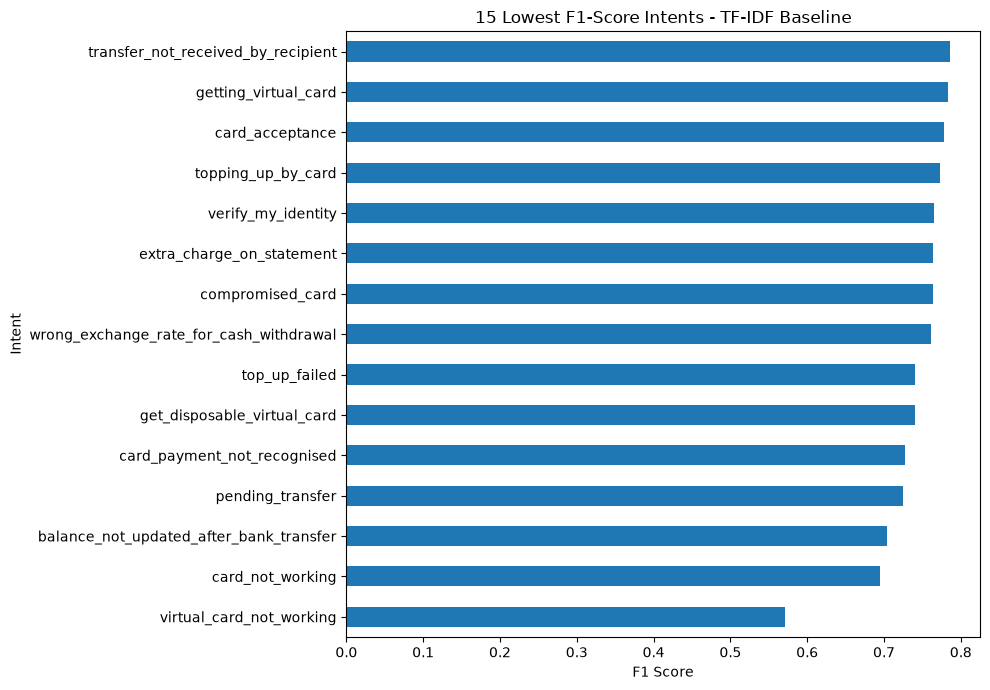

In [23]:
worst_15 = (
    class_report
    .sort_values("f1-score")
    .head(15)
)

plt.figure(figsize=(10, 7))

worst_15["f1-score"].sort_values().plot(
    kind="barh"
)

plt.title(
    "15 Lowest F1-Score Intents - TF-IDF Baseline"
)

plt.xlabel("F1 Score")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

Find the most common confusion pairs

In [24]:
error_df = pd.DataFrame({
    "text": X_test_official.values,
    "actual": y_test_official.values,
    "predicted": official_pred
})

error_df = error_df[
    error_df["actual"]
    != error_df["predicted"]
].copy()

print(
    "Incorrect predictions:",
    len(error_df)
)

Incorrect predictions: 435


In [25]:
confusion_pairs = (
    error_df
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

confusion_pairs.head(20)

,actual,predicted,count
250,virtual_card_not_working,getting_virtual_card,10
249,virtual_card_not_working,get_disposable_virtual_card,8
26,card_acceptance,card_not_working,7
211,top_up_reverted,top_up_failed,5
245,verify_my_identity,why_verify_identity,5
241,unable_to_verify_identity,verify_my_identity,5
257,why_verify_identity,verify_my_identity,5
175,pin_blocked,get_physical_card,5
180,request_refund,Refund_not_showing_up,4
57,card_swallowed,declined_cash_withdrawal,4


Inspect actual mistakes

In [26]:
for _, row in error_df.head(10).iterrows():

    print("=" * 80)

    print("CUSTOMER QUERY:")
    print(row["text"])

    print("\nACTUAL INTENT:")
    print(row["actual"])

    print("\nPREDICTED INTENT:")
    print(row["predicted"])

    print()

CUSTOMER QUERY:
How do I locate my card?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_linking

CUSTOMER QUERY:
I ordered a card but it has not arrived. Help please!

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
transfer_not_received_by_recipient

CUSTOMER QUERY:
My card has not arrived yet.

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
transfer_not_received_by_recipient

CUSTOMER QUERY:
When will I get my card?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
How long does a card delivery take?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
How do I know when my card will arrive?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
card_delivery_estimate

CUSTOMER QUERY:
I'm starting to think my card is lost because it still hasn't arrived, can you help?

ACTUAL INTENT:
card_arrival

PREDICTED INTENT:
lost_or_stolen_card

CUSTOMER QUERY:
Can I link another card to my account?

ACTUAL INTENT:
card_lin

Inspect confidence

In [27]:
def predict_intent_details(text):

    prediction = baseline_model.predict(
        [text]
    )[0]

    probabilities = baseline_model.predict_proba(
        [text]
    )[0]

    result = pd.DataFrame({
        "intent": baseline_model.classes_,
        "probability": probabilities
    }).sort_values(
        "probability",
        ascending=False
    )

    return prediction, result

In [28]:
sample_text = (
    "I was charged twice for the same transaction"
)

prediction, probabilities = (
    predict_intent_details(sample_text)
)

print(
    "Predicted intent:",
    prediction
)

probabilities.head(5)

Predicted intent: transaction_charged_twice


,intent,probability
63,transaction_charged_twice,0.980540
20,cash_withdrawal_charge,0.001423
64,transfer_fee_charged,0.001318
35,extra_charge_on_statement,0.001125
16,card_payment_fee_charged,0.001071


Test a few real-world queries

In [29]:
test_queries = [
    "My card has not arrived yet",
    "I forgot my PIN",
    "Why was I charged twice?",
    "Can I cancel a bank transfer?",
    "Someone used my card without permission",
    "My cash withdrawal is missing"
]

for query in test_queries:

    prediction = baseline_model.predict(
        [query]
    )[0]

    probabilities = baseline_model.predict_proba(
        [query]
    )[0]

    confidence = probabilities.max()

    print("=" * 70)
    print("QUERY:", query)
    print("INTENT:", prediction)
    print(
        f"CONFIDENCE: {confidence:.2%}"
    )

QUERY: My card has not arrived yet
INTENT: transfer_not_received_by_recipient
CONFIDENCE: 13.96%
QUERY: I forgot my PIN
INTENT: pin_blocked
CONFIDENCE: 51.77%
QUERY: Why was I charged twice?
INTENT: transaction_charged_twice
CONFIDENCE: 84.15%
QUERY: Can I cancel a bank transfer?
INTENT: cancel_transfer
CONFIDENCE: 24.98%
QUERY: Someone used my card without permission
INTENT: compromised_card
CONFIDENCE: 39.35%
QUERY: My cash withdrawal is missing
INTENT: pending_cash_withdrawal
CONFIDENCE: 49.07%


Inspect important TF-IDF features

In [30]:
vectorizer = (
    baseline_model.named_steps["tfidf"]
)

classifier = (
    baseline_model.named_steps["classifier"]
)

feature_names = np.array(
    vectorizer.get_feature_names_out()
)

In [31]:
target_intent = "transaction_charged_twice"

class_index = list(
    classifier.classes_
).index(
    target_intent
)

coefficients = classifier.coef_[
    class_index
]

top_indices = np.argsort(
    coefficients
)[-15:][::-1]

top_features = pd.DataFrame({
    "feature": feature_names[
        top_indices
    ],
    "weight": coefficients[
        top_indices
    ]
})

top_features

,feature,weight
0,twice,5.785326
1,duplicate,4.177923
2,charged,3.671157
3,charged twice,3.016330
4,transaction,2.924622
5,double,2.916955
6,times,2.773529
7,same,2.639265
8,the same,2.618922
9,one,2.357551


Create a reusable prediction function

In [32]:
def classify_customer_query(text):

    probabilities = baseline_model.predict_proba(
        [text]
    )[0]

    best_index = np.argmax(
        probabilities
    )

    predicted_intent = (
        baseline_model.classes_[
            best_index
        ]
    )

    confidence = probabilities[
        best_index
    ]

    return {
        "text": text,
        "intent": predicted_intent,
        "confidence": round(
            float(confidence),
            4
        )
    }

Test

In [33]:
classify_customer_query(
    "My card payment was charged twice."
)

{'text': 'My card payment was charged twice.',
 'intent': 'transaction_charged_twice',
 'confidence': 0.6516}

Final summary cell

In [34]:
print("=" * 60)
print("SUPPORTOPS AI - BANKING77 BASELINE SUMMARY")
print("=" * 60)

print(
    f"Training examples:       {len(X_train):,}"
)

print(
    f"Number of intents:       {y_train.nunique()}"
)

print("\nOFFICIAL TEST")
print(
    f"Accuracy:                {official_accuracy:.4f}"
)
print(
    f"Macro F1:                {official_f1:.4f}"
)

print("\nSTRICT TEST")
print(
    f"Accuracy:                {strict_accuracy:.4f}"
)
print(
    f"Macro F1:                {strict_f1:.4f}"
)

print(
    "\nStrict normalized overlap:",
    len(strict_overlap)
)

print("\nBaseline experiment completed.")

SUPPORTOPS AI - BANKING77 BASELINE SUMMARY
Training examples:       10,003
Number of intents:       77

OFFICIAL TEST
Accuracy:                0.8588
Macro F1:                0.8581

STRICT TEST
Accuracy:                0.8584
Macro F1:                0.8576

Strict normalized overlap: 0

Baseline experiment completed.
